In [2]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from keras.utils.vis_utils import plot_model
from keras.layers import Input,Dense,LSTM,GRU,RNN,Softmax,Dropout,AdditiveAttention,Attention
from keras import Model

In [3]:
from google.colab import files
uploaded = files.upload()

Saving attention.py to attention.py


In [ ]:
!wget https://storage.googleapis.com/gresearch/dakshina/dakshina_dataset_v1.0.tar
!tar -xvf '/content/dakshina_dataset_v1.0.tar'
filename = '/content/dakshina_dataset_v1.0/hi/lexicons/hi.translit.sampled.train.tsv'


**preprocessing**

In [54]:
# Vectorize the data.
input_texts = []
target_texts = []
input_characters = set()
target_characters = set()
with open(filename, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")
for line in lines[: len(lines) - 1]:
    target_text,input_text, attestation = line.split("\t")
    # We use "tab" as the "start sequence" character
    # for the targets, and "\n" as "end sequence" character.
    target_text = "\t" + target_text + "\n"
    for i in range(int(attestation)):
      input_texts.append(input_text)
      target_texts.append(target_text)
    for char in input_text:
        if char not in input_characters:
            input_characters.add(char)
    for char in target_text:
        if char not in target_characters:
            target_characters.add(char)

input_characters = sorted(list(input_characters))
target_characters = sorted(list(target_characters))
num_encoder_tokens = len(input_characters)
num_decoder_tokens = len(target_characters)
max_encoder_seq_length = max([len(txt) for txt in input_texts])
max_decoder_seq_length = max([len(txt) for txt in target_texts])

print("Number of samples:", len(input_texts))
print("Number of unique input tokens:", num_encoder_tokens)
print("Number of unique output tokens:", num_decoder_tokens)
print("Max sequence length for inputs:", max_encoder_seq_length)
print("Max sequence length for outputs:", max_decoder_seq_length)

Number of samples: 84942
Number of unique input tokens: 26
Number of unique output tokens: 65
Max sequence length for inputs: 20
Max sequence length for outputs: 21


In [55]:
input_token_index = dict([(char, i) for i, char in enumerate(input_characters)])
target_token_index = dict([(char, i) for i, char in enumerate(target_characters)])

reverse_input_char_index = dict((i, char) for char, i in input_token_index.items())
reverse_target_char_index = dict((i, char) for char, i in target_token_index.items())

#max_seq_length = max(max_encoder_seq_length,max_decoder_seq_length)

encoder_input_data = np.zeros(
    (len(input_texts), max_encoder_seq_length, num_encoder_tokens), dtype="float32"
)
decoder_input_data = np.zeros(
    (len(input_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
)
decoder_target_data = np.zeros(
    (len(input_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
)

for i, (input_text, target_text) in enumerate(zip(input_texts, target_texts)):
    for t, char in enumerate(input_text):
        encoder_input_data[i, t, input_token_index[char]] = 1.0
    for t, char in enumerate(target_text):
        # decoder_target_data is ahead of decoder_input_data by one timestep
        decoder_input_data[i, t, target_token_index[char]] = 1.0
        if t > 0:
            # decoder_target_data will be ahead by one timestep
            # and will not include the start character.
            decoder_target_data[i, t - 1, target_token_index[char]] = 1.0

**create model with attention**

In [56]:
from attention import AttentionLayer

latent_dim=256
encoder_inputs = Input(shape=(max_encoder_seq_length, num_encoder_tokens), name='encoder_inputs')
decoder_inputs = Input(shape=(max_decoder_seq_length, num_decoder_tokens), name='decoder_inputs')


encoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='encoder_lstm')
encoder_out, encoder_state_h, encoder_state_c = encoder_lstm(encoder_inputs)
encoder_state = [encoder_state_h,encoder_state_c]

# Set up the decoder LSTM, using `encoder_states` as initial state.
decoder_lstm = LSTM(latent_dim, return_sequences=True, return_state=True, name='decoder_lstm')
decoder_out, decoder_state_h, decoder_state_c = decoder_lstm(decoder_inputs, initial_state=encoder_state)

# Attention layer
attn_layer = AttentionLayer(name='attention_layer')
attn_out, attn_states = attn_layer([encoder_out, decoder_out])

# Concat attention output and decoder lstm output
decoder_concat_input = keras.layers.Concatenate(axis=-1, name='concat_layer')([decoder_out, attn_out])

# Dense layer
dense = Dense(num_decoder_tokens, activation='softmax', name='softmax_layer')
dense_time = keras.layers.TimeDistributed(dense, name='time_distributed_layer')
decoder_pred = dense_time(decoder_concat_input)

# Full model
model = Model(inputs=[encoder_inputs, decoder_inputs], outputs=decoder_pred)
model.compile(optimizer='adam', loss='categorical_crossentropy',metrics=['accuracy'])

In [57]:
model.fit([encoder_input_data, decoder_input_data],
        decoder_target_data,
        batch_size=32,
        epochs=10,
        validation_split=0.1)

Epoch 1/10
2389/2389 [==============================] - 134s 55ms/step - loss: 0.6905 - accuracy: 0.1439 - val_loss: 0.4854 - val_accuracy: 0.2024
Epoch 2/10
2389/2389 [==============================] - 130s 54ms/step - loss: 0.2420 - accuracy: 0.2585 - val_loss: 0.4135 - val_accuracy: 0.2227
Epoch 3/10
2389/2389 [==============================] - 130s 55ms/step - loss: 0.1633 - accuracy: 0.2835 - val_loss: 0.4195 - val_accuracy: 0.2256
Epoch 4/10
2389/2389 [==============================] - 130s 54ms/step - loss: 0.1214 - accuracy: 0.2975 - val_loss: 0.4209 - val_accuracy: 0.2331
Epoch 5/10
2389/2389 [==============================] - 135s 57ms/step - loss: 0.0951 - accuracy: 0.3063 - val_loss: 0.4270 - val_accuracy: 0.2322
Epoch 6/10
2389/2389 [==============================] - 133s 56ms/step - loss: 0.0753 - accuracy: 0.3129 - val_loss: 0.4902 - val_accuracy: 0.2281
Epoch 7/10
2389/2389 [==============================] - 130s 54ms/step - loss: 0.0615 - accuracy: 0.3182 - val_loss: 0

**inference setup**

In [100]:
Input(batch_shape=(1,None , num_encoder_tokens))

<KerasTensor: shape=(1, None, 26) dtype=float32 (created by layer 'input_17')>

In [101]:
""" Inference model """
batch_size = 1

""" Encoder (Inference) model """
encoder_inf_inputs = Input(batch_shape=(batch_size, max_encoder_seq_length, num_encoder_tokens), name='encoder_inf_inputs')
encoder_inf_out, encoder_inf_state_h, encoder_inf_state_c = encoder_lstm(encoder_inf_inputs)
encoder_inf_state = [encoder_inf_state_h,encoder_inf_state_c]

encoder_model = Model(inputs=encoder_inf_inputs, outputs=[encoder_inf_out, encoder_inf_state])

""" Decoder (Inference) model """
decoder_inf_inputs = Input(batch_shape=(batch_size, 1, num_decoder_tokens), name='decoder_word_inputs')

#encoder states for all time steps..
encoder_inf_states = Input(batch_shape=(batch_size, max_encoder_seq_length, latent_dim), name='encoder_inf_states')

decoder_init_state = [Input(batch_shape=(batch_size, latent_dim)) for i in range(2)]

decoder_inf_out, decoder_inf_state_h, decoder_inf_state_c = decoder_lstm(decoder_inf_inputs,initial_state=decoder_init_state)
decoder_inf_state = [decoder_inf_state_h,decoder_inf_state_c]

attn_inf_out, attn_inf_states = attn_layer([encoder_inf_states, decoder_inf_out])
decoder_inf_concat = keras.layers.Concatenate(axis=-1, name='concat')([decoder_inf_out, attn_inf_out])

decoder_inf_pred = keras.layers.TimeDistributed(dense)(decoder_inf_concat)
decoder_model = Model(inputs=[encoder_inf_states, decoder_init_state, decoder_inf_inputs],
                          outputs=[decoder_inf_pred, attn_inf_states, decoder_inf_state])

In [86]:
def decode_sequence(input_seq, encoder_model, decoder_model):
    # Encode the input as state vectors.
    enc_op , states_value = encoder_model.predict(input_seq)
    # Generate empty target sequence of length 1.
    target_seq = np.zeros((1, 1, num_decoder_tokens))
    # Populate the first character of target sequence with the start character.
    target_seq[0, 0, target_token_index['\t']] = 1.

    # Sampling loop for a batch of sequences
    # (to simplify, here we assume a batch of size 1).
    stop_condition = False
    decoded_sentence = []  #Creating a list then using "".join() is usually much faster for string creation
    att_mtx = []
    char_by_char = []
    while not stop_condition:
      to_split = decoder_model.predict([enc_op,states_value,target_seq])

      output_tokens, att_weights, states_value = to_split[0], to_split[1], to_split[2]

      # Sample a token
      sampled_token_index = np.argmax(output_tokens[0, 0])
      sampled_char = reverse_target_char_index[sampled_token_index]
      char_by_char.append(sampled_char)
      decoded_sentence.append(sampled_char)

      #collect the attention weights
      att_mtx.append(att_weights)
      # Exit condition: either hit max length
      # or find stop character.
      if sampled_char == '\n' or len(decoded_sentence) > max_decoder_seq_length:
          stop_condition = True

      # Update the target sequence (of length 1).
      target_seq = np.zeros((1, 1, num_decoder_tokens))
      target_seq[0, 0, sampled_token_index] = 1.
      
    
    return ("".join(decoded_sentence),char_by_char,att_mtx)

**preprocess the test data**

In [68]:
# Vectorize the test data...
filename_test = '/content/dakshina_dataset_v1.0/hi/lexicons/hi.translit.sampled.test.tsv'

input_test_texts = []
target_test_texts = []

with open(filename_test, "r", encoding="utf-8") as f:
    lines = f.read().split("\n")
for line in lines[: len(lines) - 1]:
    target_test_text,input_test_text, attestation = line.split("\t")
    # We use "tab" as the "start sequence" character
    # for the targets, and "\n" as "end sequence" character.
    target_test_text = "\t" + target_test_text + "\n"
    for i in range(int(attestation)):
      input_test_texts.append(input_test_text)
      target_test_texts.append(target_test_text)


encoder_input_test_data = np.zeros(
    (len(input_test_texts), max_encoder_seq_length, num_encoder_tokens), dtype="float32"
)
decoder_input_test_data = np.zeros(
    (len(input_test_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
)
decoder_target_test_data = np.zeros(
    (len(input_test_texts), max_decoder_seq_length, num_decoder_tokens), dtype="float32"
)

for i, (input_text, target_text) in enumerate(zip(input_test_texts, target_test_texts)):
    for t, char in enumerate(input_text):
        encoder_input_test_data[i, t, input_token_index[char]] = 1.0
    for t, char in enumerate(target_text):
        # decoder_target_data is ahead of decoder_input_data by one timestep
        decoder_input_test_data[i, t, target_token_index[char]] = 1.0
        if t > 0:
            # decoder_target_data will be ahead by one timestep
            # and will not include the start character.
            decoder_target_test_data[i, t - 1, target_token_index[char]] = 1.0

**running inference for test data**

In [102]:
for seq_index in range(50):
    # Take one sequence (part of the test set)
    # for trying out decoding.
    st=seq_index+1000
    en=seq_index+1001
    input_seq = encoder_input_test_data[st:en]
    decoded_sentence,char_by_char,att_mtx = decode_sequence(input_seq,encoder_model,decoder_model)
    print('------')
    print('Input word:', input_test_texts[st])
    #print('Target sentence:', target_test_texts[st])
    print('Predicted chars:', char_by_char)
    print('Decoded word:', decoded_sentence)


------
Input word: asian
Predicted chars: ['ए', 'श', 'ि', 'य', 'ा', '\n']
Decoded word: एशिया

------
Input word: sfc
Predicted chars: ['ए', 'स', 'ए', 'फ', 'स', 'ी', '\n']
Decoded word: एसएफसी

------
Input word: sfc
Predicted chars: ['ए', 'स', 'ए', 'फ', 'स', 'ी', '\n']
Decoded word: एसएफसी

------
Input word: sfc
Predicted chars: ['ए', 'स', 'ए', 'फ', 'स', 'ी', '\n']
Decoded word: एसएफसी

------
Input word: sk
Predicted chars: ['ए', 'स', 'स', 'े', '\n']
Decoded word: एससे

------
Input word: sk
Predicted chars: ['ए', 'स', 'स', 'े', '\n']
Decoded word: एससे

------
Input word: sk
Predicted chars: ['ए', 'स', 'स', 'े', '\n']
Decoded word: एससे

------
Input word: spf
Predicted chars: ['ए', 'स', 'प', 'ी', 'ए', 'स', '\n']
Decoded word: एसपीएस

------
Input word: spf
Predicted chars: ['ए', 'स', 'प', 'ी', 'ए', 'स', '\n']
Decoded word: एसपीएस

------
Input word: spf
Predicted chars: ['ए', 'स', 'प', 'ी', 'ए', 'स', '\n']
Decoded word: एसपीएस

------
Input word: association
Predicted chars: ['ए',

**Plotting the heatmap for 1 test point**

In [111]:
input_seq = encoder_input_test_data[20:21]
decoded_sentence,char_by_char,att_mtx = decode_sequence(input_seq,encoder_model,decoder_model)
source = input_test_texts[20].split()
char_by_char[-1]='<end>'
mtx = []
for i in range(len(char_by_char)):
  mtx.append(att_mtx[i][0][0])


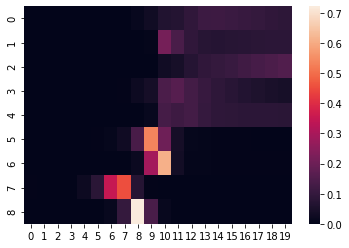

In [134]:
import matplotlib.pyplot as plt
sns.heatmap(mtx)


In [109]:
decoded_sentence

'अंग्रेजी\n'

In [110]:
char_by_char[-1] = '<end>'
char_by_char

['अ', 'ं', 'ग', '्', 'र', 'े', 'ज', 'ी', '<end>']